# Heatmap Decoration

After a heatmap is drawn, the plotting region for each component is still accessible. This means you can go back to specific parts of the heatmap and add more graphics. This is done through `decorate_*()` functions.

`list_components()` lists all named viewport components in the drawn heatmap, and then each `decorate_*` function navigates to the appropriate viewport and executes custom drawing code.

In [1]:
import numpy as np
import complexheatmap as ch
from complexheatmap import (
    Heatmap, HeatmapList, HeatmapAnnotation, rowAnnotation,
    anno_points, anno_barplot, anno_boxplot, color_ramp2,
    decorate_heatmap_body, decorate_annotation,
    decorate_column_dend, decorate_row_dend,
    decorate_row_names, decorate_column_names,
    decorate_row_title, decorate_column_title,
    decorate_dimnames, list_components
)
import grid_py as gp

## Setup: a heatmap list

We create a heatmap list with annotations and splits, then draw it to set up all the viewports.

In [2]:
np.random.seed(123)
mat = np.vstack([
    np.random.normal(2, 1, (8, 10)),
    np.random.normal(-2, 1, (4, 10))
])

ha_column1 = HeatmapAnnotation(
    points=anno_points(np.random.randn(10))
)
ht1 = Heatmap(mat, name="ht1", row_km=2,
              column_title="Heatmap 1",
              top_annotation=ha_column1,
              row_names_side="left")

ha_column2 = HeatmapAnnotation(
    type=np.array(["a"] * 5 + ["b"] * 5),
    col={"type": {"a": "red", "b": "blue"}}
)
ht2 = Heatmap(mat, name="ht2",
              column_title="Heatmap 2",
              bottom_annotation=ha_column2,
              column_km=2)

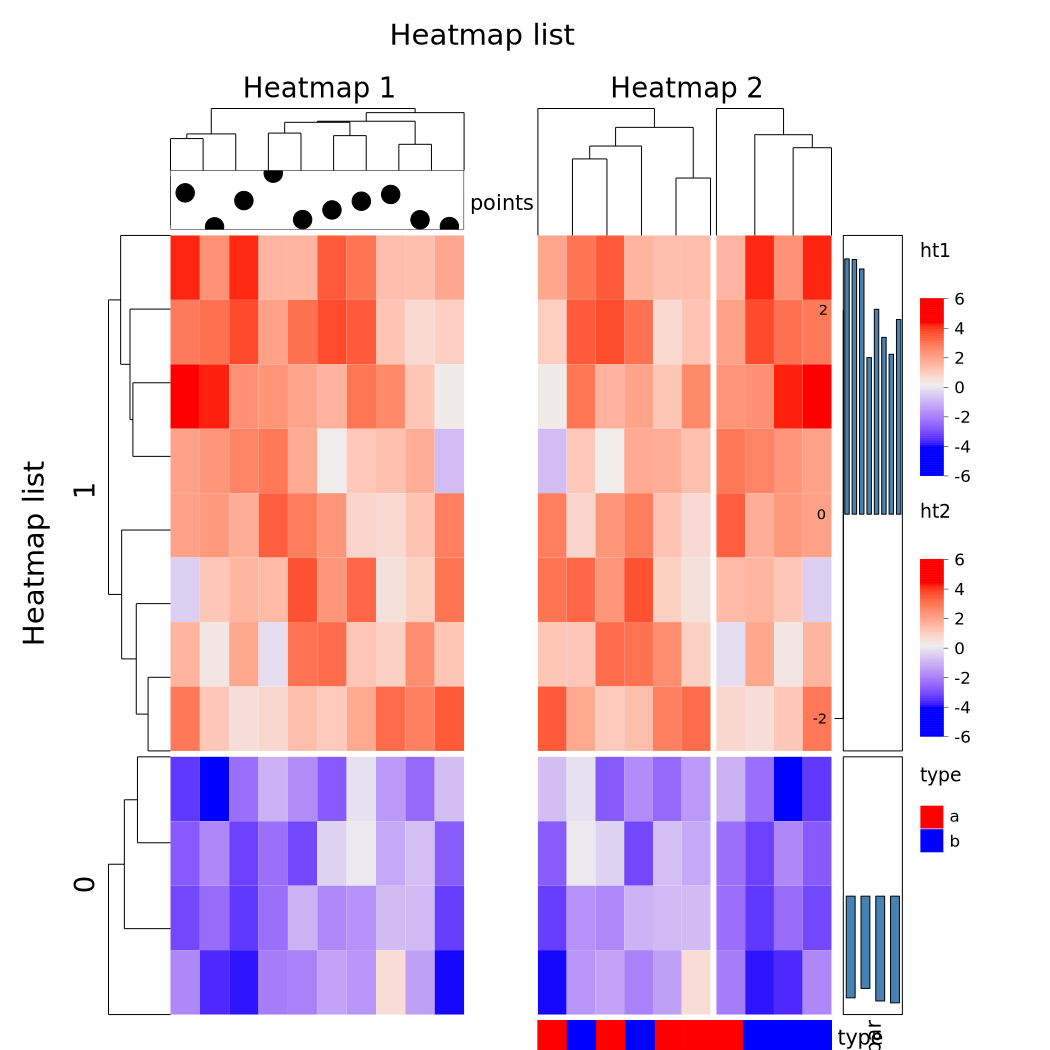

HeatmapList(['ht1', 'ht2', 'heatmap_annotation_0'], direction='horizontal')

In [3]:
ra = rowAnnotation(bar=anno_barplot(np.mean(mat, axis=1)))
ht_list = ht1 + ht2 + ra
ht_list.draw(             row_title="Heatmap list",
             column_title="Heatmap list")

## `list_components`

After drawing, `list_components()` returns the names of all viewports/components. These names are used by the `decorate_*` functions.

In [4]:
# list_components with no argument returns components from the last draw
comps = list_components()
print(f"Type: {type(comps)}")
print(f"Number of components: {len(comps)}")
if comps:
    print(f"First 10 components: {comps[:10]}")

Type: <class 'list'>
Number of components: 22
First 10 components: ['annotation_bar_1', 'annotation_bar_2', 'annotation_points', 'annotation_points_1', 'annotation_type', 'annotation_type_1', 'column_dend_ht1_1', 'column_dend_ht2_1', 'column_dend_ht2_2', 'global_column_title']


In [5]:
# list_components with a Heatmap object
ht = Heatmap(np.random.randn(10, 8), name="deco_test")
ht.make_layout()
comps = list_components(ht)
print(f"Components for single heatmap: {len(comps)}")
if comps:
    print(f"First 5: {comps[:5]}")

Components for single heatmap: 22
First 5: ['annotation_bar_1', 'annotation_bar_2', 'annotation_points', 'annotation_points_1', 'annotation_type']


In [6]:
# list_components with a HeatmapList
mat2 = np.random.randn(10, 5)
ht2_new = Heatmap(mat2, name="deco_test2")
ht_list_new = ht + ht2_new
ht_list_new.make_layout()
comps = list_components(ht_list_new)
print(f"Components for HeatmapList: {len(comps)}")

Components for HeatmapList: 22


## All Decorate Functions

The following decoration functions are available:

- `decorate_heatmap_body()` -- add graphics to the heatmap body
- `decorate_annotation()` -- add graphics to an annotation
- `decorate_column_dend()` / `decorate_row_dend()` -- add graphics on dendrograms
- `decorate_row_names()` / `decorate_column_names()` -- add graphics to name regions
- `decorate_row_title()` / `decorate_column_title()` -- add graphics to title regions
- `decorate_dimnames()` -- general dimension names decoration

Let's verify they all exist and are callable.

In [7]:
decorate_fns = [
    "decorate_heatmap_body",
    "decorate_annotation",
    "decorate_column_dend",
    "decorate_row_dend",
    "decorate_row_names",
    "decorate_column_names",
    "decorate_row_title",
    "decorate_column_title",
    "decorate_dimnames",
]

for fn_name in decorate_fns:
    fn = getattr(ch, fn_name, None)
    exists = fn is not None and callable(fn)
    print(f"{fn_name}: callable = {exists}")

decorate_heatmap_body: callable = True
decorate_annotation: callable = True
decorate_column_dend: callable = True
decorate_row_dend: callable = True
decorate_row_names: callable = True
decorate_column_names: callable = True
decorate_row_title: callable = True
decorate_column_title: callable = True
decorate_dimnames: callable = True


## Using `decorate_heatmap_body`

This function navigates to the heatmap body viewport and runs your custom drawing code. When the heatmap is split, use the `slice` argument to specify which slice to decorate.

The function takes:
- `heatmap_name`: the name of the heatmap
- `code`: a callable that performs grid drawing commands
- `slice`: which row slice (1-indexed) to decorate

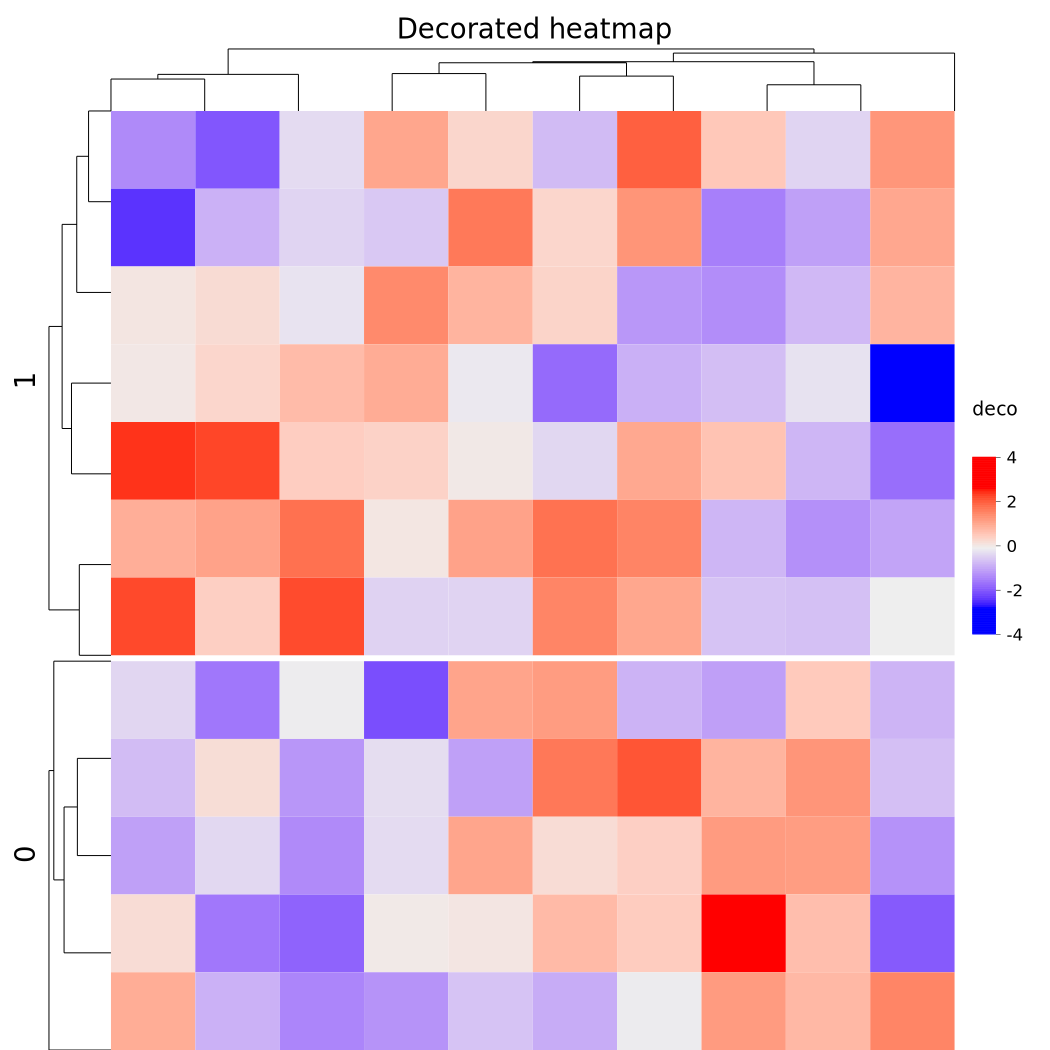

In [8]:
# Draw a heatmap with row split
np.random.seed(123)
mat_deco = np.random.randn(12, 10)
ht = Heatmap(mat_deco, name="deco", row_km=2, column_title="Decorated heatmap")
ht_drawn = ht.draw()

# Decorate: add a vertical dashed line in slice 2
def add_line():
    gp.grid_lines([0.5, 0.5], [0, 1], gp={"lty": 2, "lwd": 2})
    gp.grid_text("decorated", 0.5, 0.5)

decorate_heatmap_body("deco", add_line, slice=2)

## Using `decorate_annotation`

For annotations created by `anno_points`, `anno_barplot`, etc., you can go back to their plotting region and add reference lines or labels.

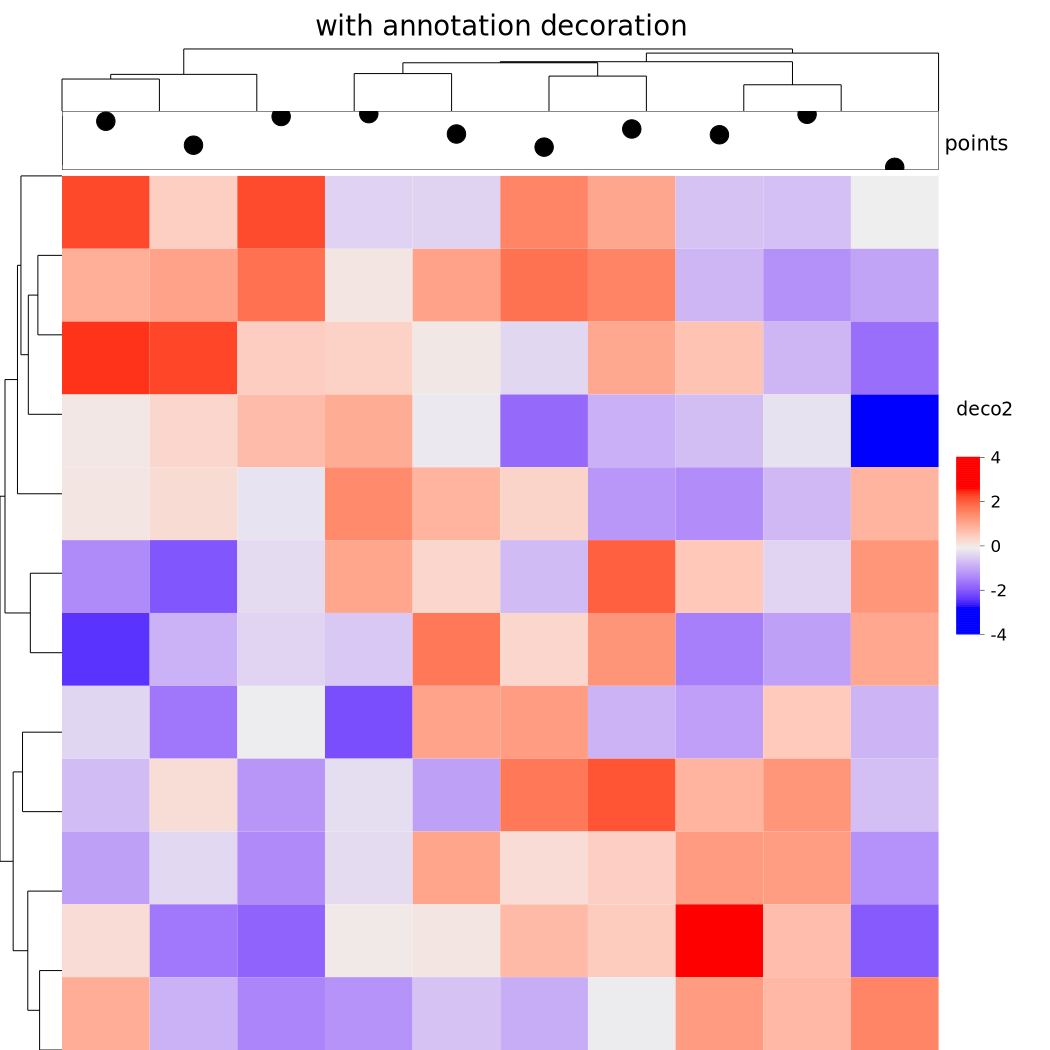

In [9]:
# Draw heatmap with an annotation
ha_top = HeatmapAnnotation(points=anno_points(np.random.randn(10)))
ht = Heatmap(mat_deco, name="deco2",
             top_annotation=ha_top,
             column_title="with annotation decoration")
ht.draw()

# Add a horizontal reference line at y=0 in the annotation
def add_ref_line():
    gp.grid_lines([0, 1], [0, 0], default_units="native",
                  gp={"col": "red"})

decorate_annotation("points", add_ref_line)

## Using `decorate_row_names`

You can highlight or add background to row name regions.

In [10]:
def highlight_row_names():
    gp.grid_rect(gp={"fill": "#FF000040"})

# This would highlight row names in slice 2 (if the heatmap was split)
# decorate_row_names("deco", highlight_row_names, slice=2)

## Using `decorate_column_dend`

You can add colored rectangles behind dendrogram branches to highlight clusters.

In [11]:
def highlight_dend():
    gp.grid_rect(gp={"fill": "#00FF0020", "col": None})

# decorate_column_dend("deco2", highlight_dend)

## Example: Barplot on Empty Annotation

A common pattern is to use `anno_empty` to reserve space, draw the heatmap, then use `decorate_annotation` to fill in custom graphics based on the final row ordering.

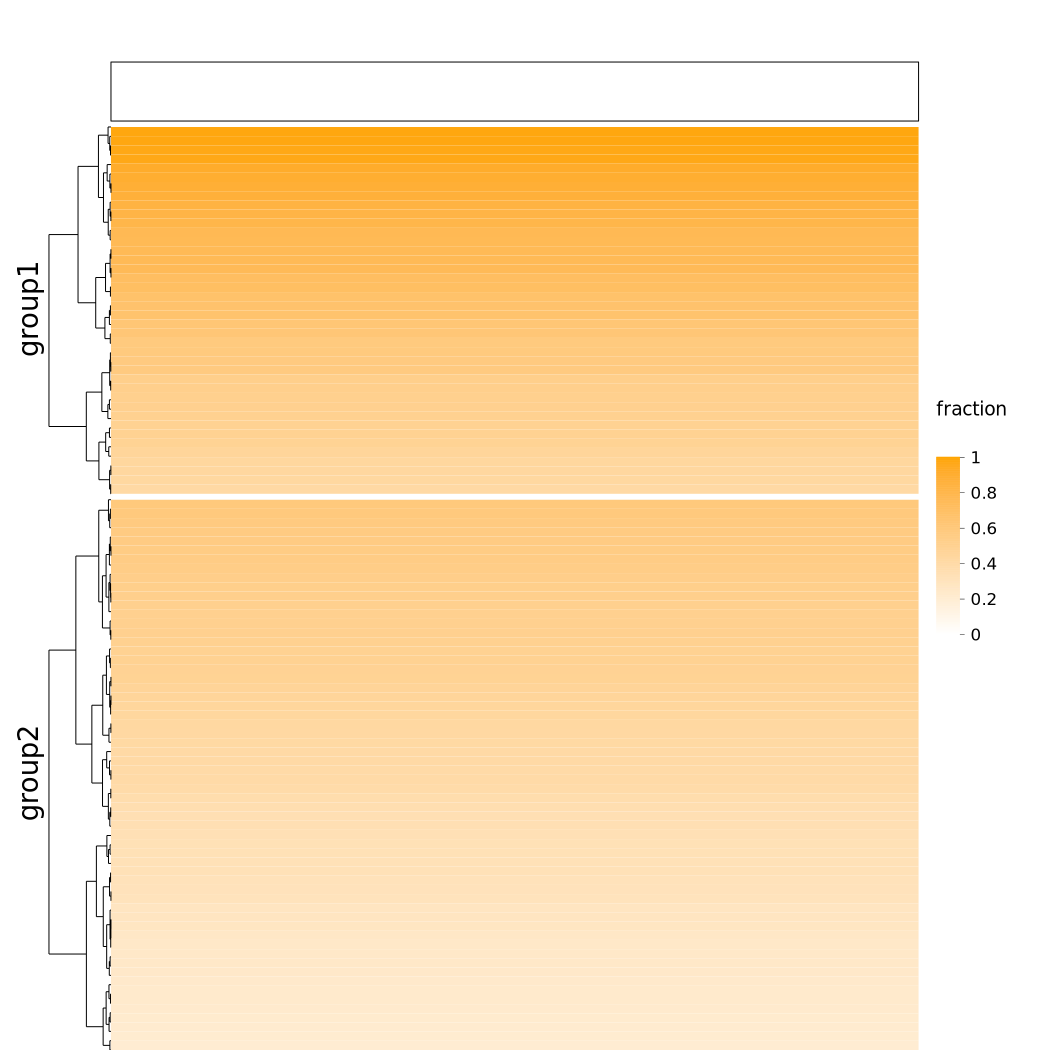

In [12]:
from complexheatmap import anno_empty

np.random.seed(42)
frac = np.concatenate([
    np.random.uniform(0.4, 1.0, 40),
    np.random.uniform(0.2, 0.6, 60)
])
col_fun = color_ramp2([0, 1], ["white", "orange"])

ht = Heatmap(
    frac.reshape(-1, 1), name="fraction", col=col_fun,
    top_annotation=HeatmapAnnotation(
        barplot=anno_empty()
    ),
    row_split=np.array(["group1"] * 40 + ["group2"] * 60)
)
ht.draw()

## Example: Adding Titles for Row Annotations

Row annotations do not have a built-in title. You can add one via decoration.

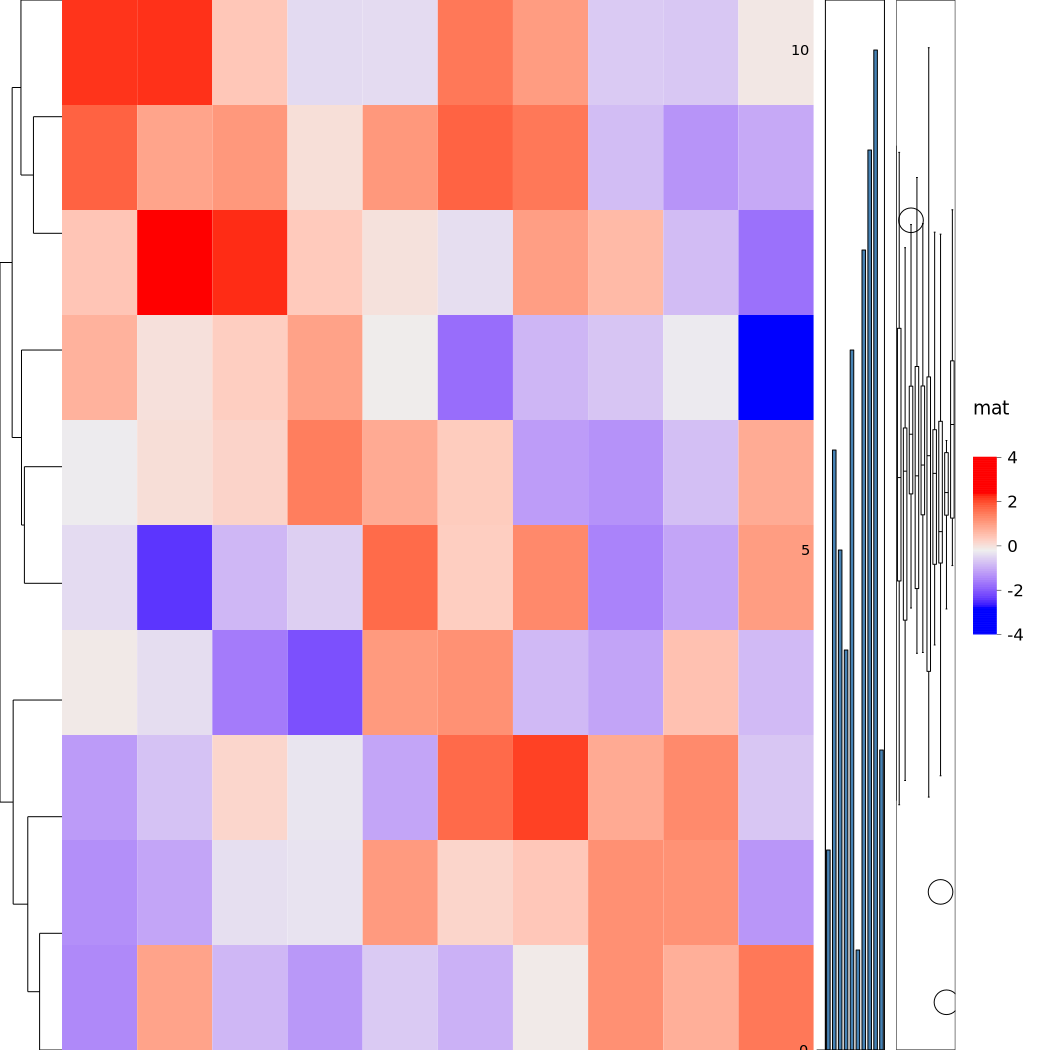

HeatmapList(['mat', 'heatmap_annotation_1', 'heatmap_annotation_2'], direction='horizontal')

In [13]:
np.random.seed(123)
m = np.random.randn(10, 10)

ht_list = (
    Heatmap(m, name="mat", show_column_dend=False) +
    rowAnnotation(foo=anno_barplot(np.arange(1, 11))) +
    rowAnnotation(bar=anno_boxplot(np.random.randn(10, 10)))
)
ht_list.draw()

## Summary

This tutorial covered:

- `list_components()` to enumerate all viewport names after drawing
- `decorate_heatmap_body()` to add custom graphics to heatmap body slices
- `decorate_annotation()` to add graphics on annotations (reference lines, labels)
- `decorate_column_dend()` / `decorate_row_dend()` for dendrogram decoration
- `decorate_row_names()` / `decorate_column_names()` for highlighting name regions
- `decorate_row_title()` / `decorate_column_title()` for title regions
- The `anno_empty` + `decorate_annotation` pattern for fully custom annotations
- All decorate functions are confirmed callable in the Python port